In [8]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import CategoricalNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [10]:
df = pd.read_csv("play_tennis.csv")

df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [12]:
print(df.shape)

(14, 6)


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day       14 non-null     object
 1   outlook   14 non-null     object
 2   temp      14 non-null     object
 3   humidity  14 non-null     object
 4   wind      14 non-null     object
 5   play      14 non-null     object
dtypes: object(6)
memory usage: 804.0+ bytes
None


In [14]:
print(df.isnull().sum())

day         0
outlook     0
temp        0
humidity    0
wind        0
play        0
dtype: int64


In [15]:
print(df.describe(include="object"))

       day outlook  temp humidity  wind play
count   14      14    14       14    14   14
unique  14       3     3        2     2    2
top     D1   Sunny  Mild     High  Weak  Yes
freq     1       5     6        7     8    9


In [16]:
df.drop("day", axis=1, inplace=True)

df.head()

,outlook,temp,humidity,wind,play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


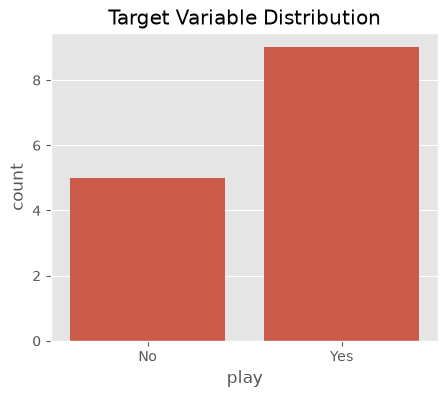

In [17]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="play"
)

plt.title("Target Variable Distribution")

plt.show()

In [18]:
encoder = OrdinalEncoder()

df_encoded = pd.DataFrame(

    encoder.fit_transform(df),

    columns=df.columns

)

df_encoded.head()

,outlook,temp,humidity,wind,play
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0


In [19]:
X = df_encoded.drop("play", axis=1)

y = df_encoded["play"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.25,

    random_state=42
)

In [21]:
model = CategoricalNB()

model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[0., 2...[2., 2., 2.]]), array([[1., 1...[3., 1., 2.]]), array([[3., 1... [2., 4.]]), array([[3., 1... [2., 4.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[4.,6.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.92,-0.51]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[float64](2,)","[0.,1.]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-1.94...-1.09861229]]), array([[-1.25...-1.09861229]]), array([[-0.40...-0.47000363]]), array([[-0.40...-0.47000363]])]"


In [22]:
prediction = model.predict(X_test)

prediction

array([1., 0., 0., 1.])

In [23]:
accuracy = accuracy_score(

    y_test,

    prediction

)

print("Accuracy :",accuracy)

Accuracy : 0.75


In [24]:
print(classification_report(

    y_test,

    prediction

))

              precision    recall  f1-score   support

         0.0       0.50      1.00      0.67         1
         1.0       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



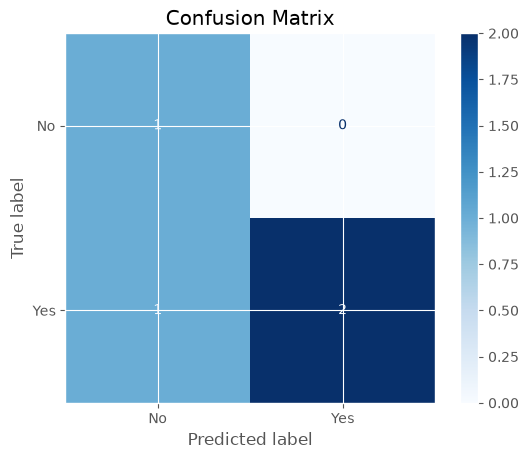

In [25]:
cm = confusion_matrix(

    y_test,

    prediction

)

ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["No","Yes"]

).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [26]:
new_data = pd.DataFrame({

    "outlook":["Sunny"],

    "temp":["Cool"],

    "humidity":["High"],

    "wind":["Strong"]

})

In [28]:
new_data = pd.DataFrame({

    "outlook":["Sunny"],
    "temp":["Cool"],
    "humidity":["High"],
    "wind":["Strong"],
    "play":["No"]      # Dummy value

})

new_data = pd.DataFrame(
    encoder.transform(new_data),
    columns=new_data.columns
)

# Remove target column before prediction
new_data = new_data.drop("play", axis=1)

prediction = model.predict(new_data)

print(prediction)

[0.]


In [30]:
if result[0] == 1:

    print("Prediction : Play Tennis")

else:

    print("Prediction : Do Not Play Tennis")

Prediction : Do Not Play Tennis


In [31]:
probability = model.predict_proba(new_data)

print(probability)

[[0.63523573 0.36476427]]


In [32]:
performance = pd.DataFrame({

    "Metric":["Accuracy"],

    "Value":[accuracy]

})

performance

,Metric,Value
0,Accuracy,0.75
